In [2]:
%matplotlib inline
import warnings
import inspect
import matplotlib.pyplot as plt
import IPython.display
import numpy as np
from cued_sf2_lab.familiarisation import load_mat_img, plot_image
from cued_sf2_lab.dct import colxfm, dct_ii

# 8 The Lapped Bi-orthogonal Transform (LBT)

<!-- sorry for the nasty HTML, markdown is bad for figures -->

<figure style="text-align: center">
<div class="row">
<figure class="col-md-4 col-md-offset-1">
<img src="figures/lbt.png" style="max-height: 350px" />
<figcaption>(a) Lapped Bi-orthogonal Transform</figcaption>
</figure>

<figure class="col-md-5 col-md-offset-1">
<img src="figures/pot.png" style="max-height: 350px" />
<figcaption>(b) Photo Overlap Transform and a DCT</figcaption>
</figure>
</div>
<div class="row">
<figcaption>
<br />

Figure 4: (a) An LBT transforms overlapping sections of X to create Y. (b) In some cases
this can be interpreted as pre-filtering with a POT, followed by a DCT.</figcaption></div></figure>

One of the difficulties with the DCT is that it processes each block separately and hence
does not take advantage of any correlation between blocks. A possible solution to this is
to use a _Lapped Bi-orthogonal Transform (LBT)_. These transform overlapping blocks in `X`
to generate smaller non-overlapping blocks in `Y`. In the left-hand figure above, 16 values
in `X` are used to generate each set of 8 values in `Y`.

LBTs are quite complicated to derive and analyse: however one of the most popular forms<sup>3</sup>
can also be represented as a pre-filtering operation before performing the DCT described
in the previous section.
In this case the pre-filtering (or post-filtering for the reverse
operation) is sometimes known as a _Photo Overlap Transform or POT_. A POT followed
by a DCT is then equivalent to a particular type of LBT.

The right-hand figure above demonstrates this. The POT is first performed on a section
of data `X`, shifted by `N/2`, so that it runs across the block boundaries of the subsequent
DCT. Ignoring this block shift for a moment, the forward operation for a 2D image `X` is:


$$Y = C ∗ Pf ∗ X ∗ Pf ′ ∗ C′$$

or in reverse

$$ X = Pr′ ∗ C′ ∗ Y ∗ C ∗ Pr $$

<hr />
<small><sup>3</sup>The type-II fast lapped (bi-)orthogonal transform, or LOT-II</small>

## 8.1 Applying the LBT to images

In [3]:
X, cmaps_dict = load_mat_img(img='lighthouse.mat', img_info='X', cmap_info={'map', 'map2'})
X = X - 128.0

The pre-filtering `Pf ∗ X ∗ Pf′` (with the correct block shift) is straightforward in Python:

```python
t = np.s_[N//2:-N//2]  # N is the DCT size, I is the image size
Xp = X.copy()  # copy the non-transformed edges directly from X
Xp[t,:] = colxfm(Xp[t,:], Pf)
Xp[:,t] = colxfm(Xp[:,t].T, Pf).T
```

This is followed by the DCT `C` as before. In the reverse operation, the inverse DCT `C’` is
performed first, followed by Pr’:
```python
Zp = Z.copy()  #copy the non-transformed edges directly from Z
Zp[:,t] = colxfm(Zp[:,t].T, Pr.T).T
Zp[t,:] = colxfm(Zp[t,:], Pr.T)
```

We have provided a function `pot_ii(N, s)` which will generate a forward (pre-filtering,
`Pf`) and reverse (post-filtering, `Pr`) matrix of size `N` with scaling factor `s`.

In [4]:
from cued_sf2_lab.lbt import pot_ii


In [5]:
#IPython.display.Code(inspect.getsource(pot_ii), language='python')

Edit your code
for performing DCT analysis so that it can pre-filter `X` with `Pf` before the forward DCT,
then post-filter `Z` with `Pr` after the inverse DCT. Confirm that, without quantisation, this
correctly recreates the original image, i.e. `Zp = X`. Use `Pf, Pr = pot_ii(N)` with the
default scaling value `s`.

In [6]:
# your code here
def lbt(X, N, s = 1.0):
    # Your code here
    Pf, Pr = pot_ii(N, s)
    t = np.s_[N//2:-N//2]
    #print(t)
    Xp = X.copy()
    Xp[t,:] = colxfm(Xp[t,:], Pf)
    Xp[:,t] = colxfm(Xp[:,t].T, Pf).T
    C = dct_ii(N)
    Xp = colxfm(colxfm(Xp, C).T, C).T
    return Xp, Pr
def ilbt(Y, N, Pr):
    C = dct_ii(N)
    Yp = colxfm(colxfm(Y.T, C.T).T, C.T).T
    t = np.s_[N//2:-N//2]
    Yp[:,t] = colxfm(Yp[:,t].T, Pr.T).T
    Yp[t,:] = colxfm(Yp[t,:], Pr.T)
    return Yp.T

## 8.2 Quantisation and coding efficiency

The scaling factor `s` determines the degree of bi-orthogonality. If `s = 1` then Pf is the same
as Pr, otherwise `1 < s < 2` weights the relative contributions of `Pf` and `Pr` un-equally.

<div class="alert alert-block alert-danger">

For an 8 × 8 DCT, try implementing an LBT with POT scaling factors varying from $1$
to $2$ ($\sqrt{2}$ is often a good choice). In each case find the quantisation step which makes
the rms error match the directly quantised image. Note the compression ratios and find
the scaling factor which maximises these. Also note the visual features in these images.</div>

In [7]:
from cued_sf2_lab.laplacian_pyramid import bpp
from cued_sf2_lab.laplacian_pyramid import quantise 
from cued_sf2_lab.dct import regroup
def dctbpp(Y, N):
    # Your code here
    num_of_bits = 0
    L = Y.shape[0]//N
    Yr = regroup(Y, N)/N
    for i,j in [(i,j) for i in range(N) for j in range(N)]:
        sub_image = Yr[L*i:L*i+L,L*j:L*j+L]
        #print((L*i,L*i+L,L*j,L*j+L),bpp(sub_image))
        num_bits = bpp(sub_image)*sub_image.size
        num_of_bits += num_bits
        #print(f"Block ({i},{j}): {num_bits}")
    #print(f"Total bits: {num_of_bits}")
    return num_of_bits
def num_of_bits(X):
    return bpp(X)*X.size


In [8]:

def find_quantisation_step_for_LBT(X,Y,Pr,N, targetDirectStep = 17, smin = 1, smax = 100):
    targetRMS = np.std(quantise(X, targetDirectStep) - X)
    print(f"targetRMS: {targetRMS}")
    def error(step):
        Z = ilbt(quantise(Y, step), N=N, Pr=Pr)
        return np.std(Z - X) - targetRMS
    step = (smin + smax) / 2
    #err = error(step)
    while smax - smin > 0.001:
        step = (smin + smax) / 2
        err = error(step)
        #print(f"step: {step}, error: {err}")
        if err > 0:
            smax = step
        else:
            smin = step
    return step

targetRMS: 4.861168497356846
s: 1.0, step: 23.3700, compression ratio: 3.0195354673329837
error: 4.861226367366347
targetRMS: 4.861168497356846
s: 1.1, step: 24.1993, compression ratio: 3.0814079062355906
error: 4.861184428930002
targetRMS: 4.861168497356846
s: 1.2, step: 24.8610, compression ratio: 3.115843002478302
error: 4.861259151135946
targetRMS: 4.861168497356846
s: 1.3, step: 25.4381, compression ratio: 3.1324523346200204
error: 4.861063912720948
targetRMS: 4.861168497356846
s: 1.4, step: 25.8852, compression ratio: 3.134256295979998
error: 4.861293117150714
targetRMS: 4.861168497356846
s: 1.5, step: 26.2266, compression ratio: 3.1220323594132062
error: 4.861100777527492
targetRMS: 4.861168497356846
s: 1.6, step: 26.3958, compression ratio: 3.0853042971988676
error: 4.86053150443766
targetRMS: 4.861168497356846
s: 1.7, step: 26.4653, compression ratio: 3.0345521594117892
error: 4.8611559988491795
targetRMS: 4.861168497356846
s: 1.8, step: 26.5514, compression ratio: 2.985036807

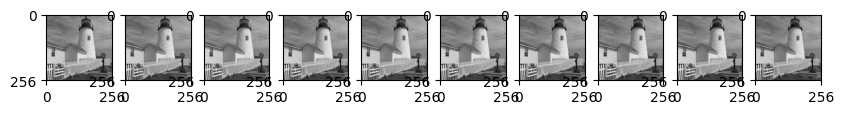

In [9]:
# your code here
fig, axs = plt.subplots(1,10, figsize=(10,100))
for s in np.arange(1, 2.0, 0.1):
    Y, Pr = lbt(X, N=8, s=s)
    step = find_quantisation_step_for_LBT(X,Y,Pr,N=8)
    #print(Y.shape)
    Yq = quantise(Y, step)
    compression_ratio = num_of_bits(quantise(X,17))/dctbpp(Yq, N=8)
    print(f"s: {s:.1f}, step: {step:.4f}, compression ratio: {compression_ratio}")
    Z = ilbt(Yq, N=8, Pr=Pr)
    #print(Z.shape)
    row_num = int((s-1)*10)
    print("error:", np.std(X-Z))
    #plot_image(Y, ax=axs[row_num, 0], cmap=cmaps_dict['map'])
    plot_image(Z, ax=axs[row_num], cmap=cmaps_dict['map'])
# s = np.sqrt(2)
# Y, Pr = lbt(X, N=8, s=s)
# print(Y.shape)
# Z = ilbt(Y, N=8, Pr=Pr)
# print(Z.shape)
# fig, axs = plt.subplots(1,2)

# plot_image(Y, ax=axs[0], cmap=cmaps_dict['map'])
# plot_image(Z, ax=axs[1], cmap=cmaps_dict['map'])

The POT can often improve both compression and block smoothing, since the pre-filter
acts to reduce correlations between each DCT sub-block, whilst the inverse post-filter
acts to remove the discontinuities between sub-blocks. This is rather different from the
operation of the DCT. Investigate this by looking at the basis functions, as you did with
the DCT:

(8, 10)
(80, 1)


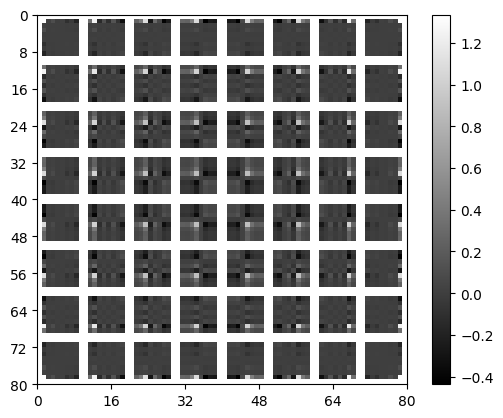

In [15]:
Pf, Pr = pot_ii(8,s=2)
bases = np.concatenate([np.full((8,1), np.nan), Pf, np.full((8,1), np.nan)], axis=1)
print(bases.shape)
bases = bases.reshape(-1, 1)
print(bases.shape)
fig, ax = plt.subplots()
im_obj = plot_image(bases @ bases.T, ax=ax)
fig.colorbar(im_obj, ax=ax);

<div class="alert alert-block alert-danger">

Look at both these bases and the pre-filtered image `Xp`, using different scaling factors
`s`, and comment on the visual effect of varying these scaling factors. You may need to
multiply `Xp` by up to 0.5 to display it better.</div>

slice(4, -4, None)
slice(4, -4, None)
slice(4, -4, None)
slice(4, -4, None)
slice(4, -4, None)
slice(4, -4, None)
slice(4, -4, None)
slice(4, -4, None)
slice(4, -4, None)
slice(4, -4, None)


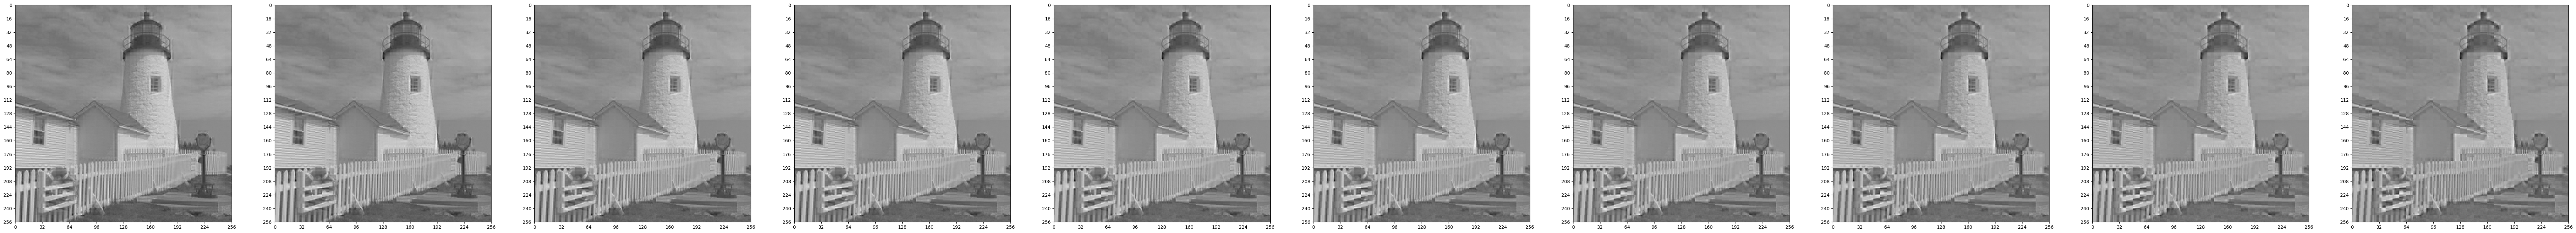

In [11]:
# your code here
N = 8
fig, axs = plt.subplots(1,10, figsize=(100,10))
for s in np.arange(1, 2.0, 0.1):
    
    Pf, Pr = pot_ii(N, s)
    t = np.s_[N//2:-N//2]
    print(t)
    Xp = X.copy()
    Xp[t,:] = colxfm(Xp[t,:], Pf)
    Xp[:,t] = colxfm(Xp[:,t].T, Pf).T
    plot_image(Xp, ax=axs[int((s-1)*10)], cmap=cmaps_dict['map'])

With this type of POT / DCT combination it is common to use smaller DCT block sizes
but to code several blocks together. Hence a more accurate estimate of the number of bits
is found by always using 16 × 16 blocks, i.e. regroup `Yq` with the correct size `N` to give
`Yr`, but then always use `dctbpp(Yr, 16)`.

<div class="alert alert-block alert-danger">

Investigate the relative visual and compression performance of LBTs with 4 × 4, 8 × 8
and 16 × 16 blocks, using the scaling factor you have previously selected. As before, be
careful to match the rms error with a directly quantised image.</div>

targetRMS=4.861168497356846
N=4, step=28.86187744140625, num_bits=88005.4400804667, error=4.861319093281809, compression_ratio=2.5921015372471246
targetRMS=4.861168497356846
N=8, step=25.94940185546875, num_bits=77315.66946207463, error=4.860923700839935, compression_ratio=2.9504890548815053
targetRMS=4.861168497356846
N=16, step=22.94024658203125, num_bits=76347.59504698029, error=4.861666410517301, compression_ratio=2.987900750224221


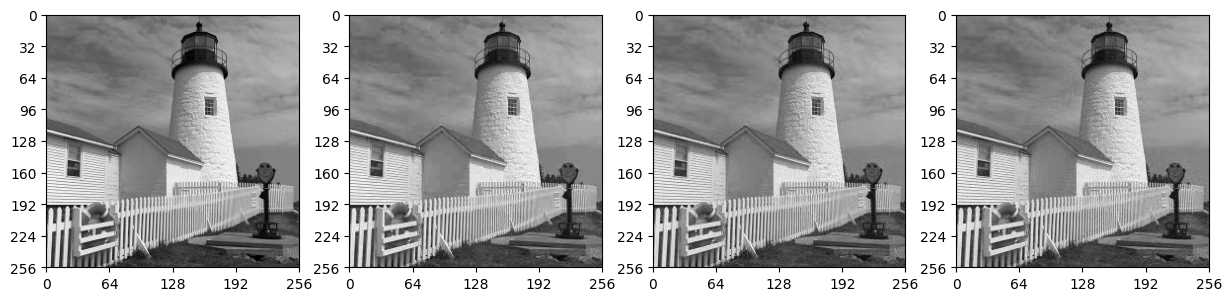

In [12]:
# your code here


def FindStep(X, N, targetStep = 17, s = 1,  min_step = 1, max_step = 100.0):
    targetRMS = np.std(X-quantise(X, targetStep))
    print(f"targetRMS={targetRMS}")
    def error(step):
        Xp, Pr = lbt(X, N, s)
        Xp = quantise(Xp, step)
        Z = ilbt(Xp, N, Pr)
        return np.std(X-Z) - targetRMS
    smin = min_step
    smax = max_step
    smid = (smin + smax) / 2
    while smax - smin > 0.01:
        smid = (smin + smax) / 2
        err = error(smid)
        #print(f"s={smid}, error={err}")
        if err > 0:
            smax = smid
        else:
            smin = smid
    return smid




fig, axs = plt.subplots(1,4, figsize=(15,5))
s =np.sqrt(2)
i=1
plot_image(X, ax=axs[0], cmap=cmaps_dict['map'])
for N in [4, 8, 16]:
    step = FindStep(X, N, s=s)

    Xp, Pr = lbt(X, N, s)
    Xp = quantise(Xp, step)
    ilbt_Xp = ilbt(Xp, N, Pr)

    Yr = regroup(Xp, N)
    num_bits = dctbpp(Yr, 16)

    

    compression_ratio = num_of_bits(quantise(X,17)) / num_bits
    print(f"N={N}, step={step}, num_bits={num_bits}, error={np.std(X-ilbt_Xp)}, compression_ratio={compression_ratio}")
    plot_image(ilbt_Xp, ax=axs[i], cmap=cmaps_dict['map'])
    i += 1